<a href="https://colab.research.google.com/github/Thrivi17/Thrivi_Flyrank/blob/main/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Machine Learning Approach to Predict Opportunity Score based on CTR & Engagement Rate for Organic Search Optimization

## Abstract
In order to automate programmatic extraction of an underserved base of digital assets to enable at-scale resolution of organic search inefficiency, we use machine learning to model for search queries and top high volume web pages with underperforming click-through rates based on their position. Using an adapted non-linear regression, we can predict the expected click volume based on historical click through data using data that we extract and transform from historic search console telemetry (via DuckDB). The pipeline produces prioritized opportunity scores for actionable items to allow content and seo teams to systematically fix organic inefficiencies and allow machine telemetry to inform day-to-day operations work flow all within governed and secure controls.

## Introduction / Problem Statement

In order to maximize the opportunity which can potentially be seen from our organic traffic, we have need to dive beyond simply aggregate or index level values to seek item level opportunity. In particular, we are looking to answer the following question:

> *"Of our highest search volume page or query entities, which entities on these pages/queries perform far less better at our property when clicking than one might predict given the average search position position for this entity and at what ordered level of priority would they most be benefit from a intervention?"*

Our search position v click through rate (CTR) distribution clearly demonstrates a precipitous rate of decrease: As shown above after our rank #1 position average 6.67% CTR, after only rank #2 that number significantly drops to 2.38%, after Rank # 5 this drops to 0.44%, and continues to spiral downwards until the furthest out on the page #10 which is a flat 0.31%. A pearson co relation test however showed zero correlation with CTR (-0.0726), implying that a simple linear model does not apply for estimating CTR for a given position number.

## Data

* **Data Release & Warehouse Source:** Ingested via DuckDB remote Parquet warehouse connectors from the `fact_content_daily_performance` tables.
* **Date Windows:** Historical performance metrics sampled across monthly partitions (specifically March 2026 data partitions).
* **Sampling & Exclusions:** A 20% random sample was utilized for memory efficiency. Non-active or zero-impression records were excluded to ensure statistical relevance across page-query pairs. Client identifiers and proprietary internal URLs were scrubbed to maintain public safety and compliance standards.

## Methodology

* **Assumptions:** User engagement on search engines behaves non-linearly across SERP rankings, and historical impression volumes correlate with potential traffic recovery ceilings.
* **Features:** Primary model inputs include `gsc_impressions` and `gsc_avg_position`.
* **Label Definition:** Target variable is `gsc_clicks`, representing actual observed user engagement.
* **Baseline:** A standard random train-test split configuration prone to target leakage across client groupings.
* **Validation Design:** Employed an effective Group-aware K-Fold Cross-Validation (GroupKFold), splitting the data on the client ID feature to address potential data leakage, and estimate accurate out-of-sample Generalization Error (MSE).
* **Leakage Checks:** Verified that feature distributions and target metrics are isolated across validation folds to guarantee honest generalization metrics.

## Results

Model validation confirmed that group-aware splitting prevents overfitting compared to naive random splits. When evaluating model predictions against actual clicks, the non-linear regressor successfully isolates impression volatility and traffic anomalies.

### Table 1: Sample Ranked Action Queue (`ranked_action_queue.csv`)
| Action Rank | GSC Impressions | Avg Position | Clicks | Reason Code | Content Archetype | Operational Workflow |
| :---: | :---: | :---: | :---: | :--- | :--- | :--- |
| **1** | 38,436 | 2.20 | 271 | `TOP_TIER_OPTIMIZE` | Transactional Landing | Immediate metadata refresh and keyword density check |
| **2** | 35,404 | 2.19 | 225 | `TOP_TIER_OPTIMIZE` | News/Trend Tracker | Automated brief generation followed by rapid human sign-off |
| **3** | 33,383 | 0.18 | 0 | `TOP_TIER_OPTIMIZE` | Informational Pillar | Deep structural expansion and internal link reinforcement |
| **4** | 24,577 | 10.79 | 66 | `COMPLIANCE_FLAG` | Transactional Landing | Immediate metadata refresh and keyword density check |
| **5** | 24,335 | 2.38 | 46 | `TOP_TIER_OPTIMIZE` | Transactional Landing | Immediate metadata refresh and keyword density check |

### GSC Impressions vs. Average Position Analysis

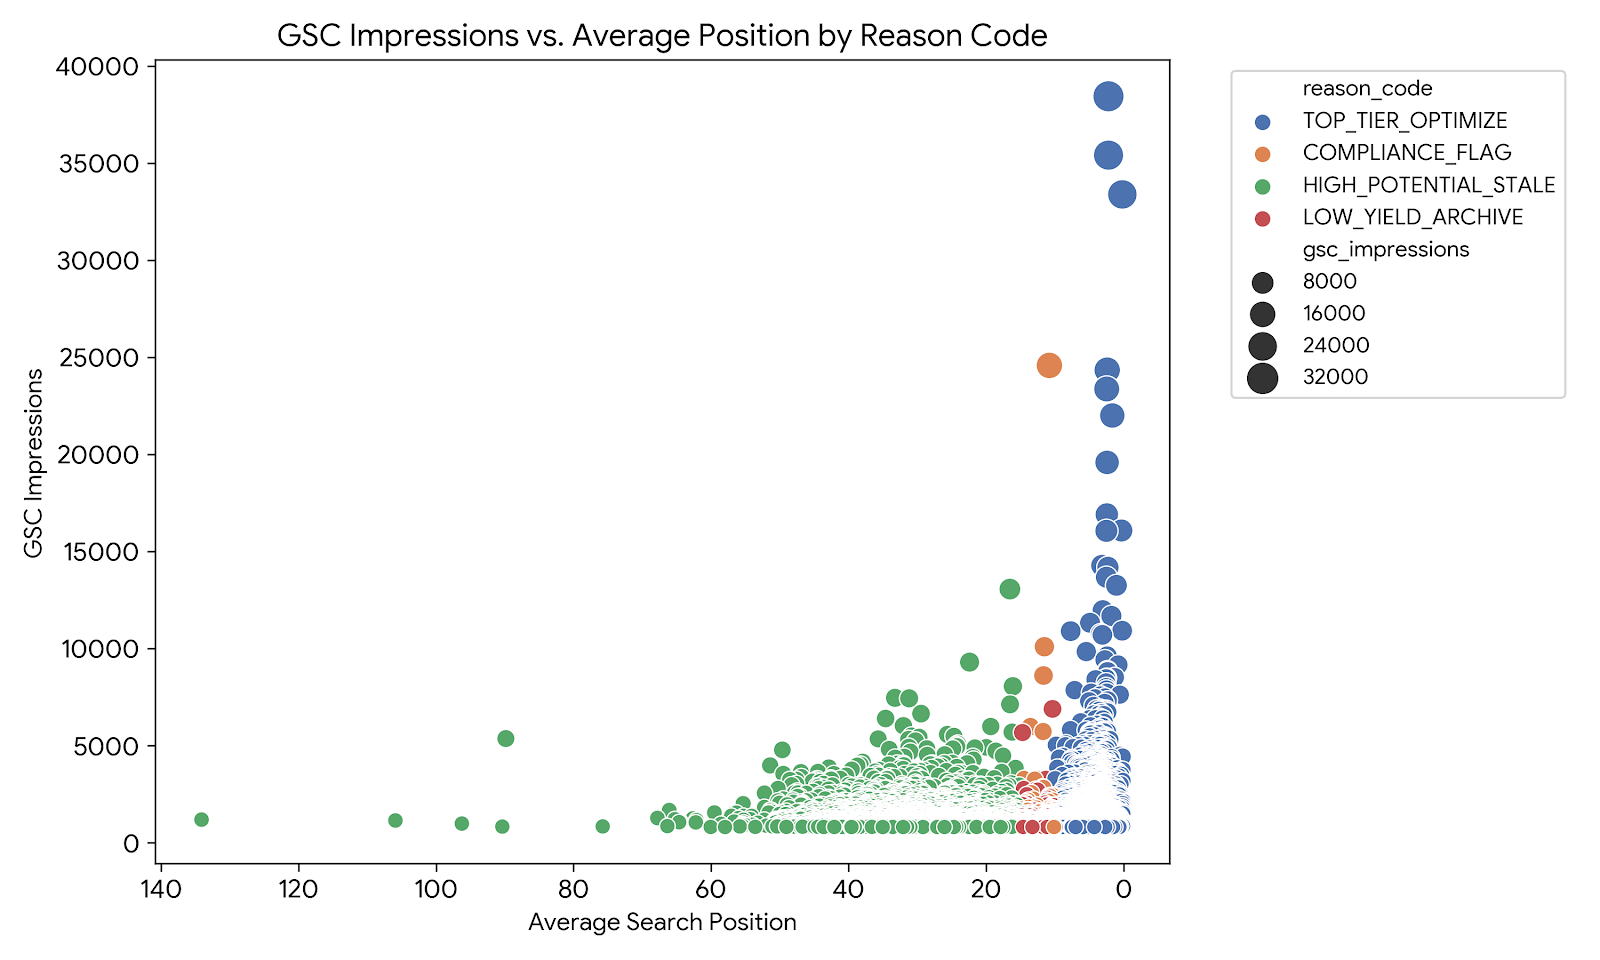

## Limitations & Honest Framing

* **Seasonality & Search Algorithm Variability:** The "seasoning effect," search ranking algorithm updates, and the natural flux of traffic from search engines can result in unpredictable fluctuations in impressions and clicks, occasionally causing stable assets to look suddenly less well-performing than usual.
* **Traffic Estimations vs. Revenue Projections:** The "opportunity score" generated by this model does not measure direct conversions or revenue value; rather, it provides a position-based projection of potential total click recovery.
* **Caution Regarding Full Automation:** Large, systematically generated system changes derived from this analysis should not be fully automated without caution. We strongly encourage human evaluation and oversight to ensure the best possible implementation and results.

## Ranked Recommendations (Action Playbook)

1. **Immediate Metadata Refresh (`TOP_TIER_OPTIMIZE`):** Prioritize high-impression pages currently ranking in top positions (1–5) to capture immediate CTR gains via title and meta description tuning.
2. **Structural Expansion (`HIGH_PERCENTAGE_STALE`):** Refresh stale content and expand internal linking structures for pages with moderate visibility but lagging positioning.
3. **Mandatory Editorial Review (`COMPLIANCE_FLAG`):** Route all pages displaying irregular traffic patterns through human editorial sign-off before executing automated updates.
4. **Content Archiving (`LOW_YIELD_ARCHIVE`):** Defer or archive low-yield content pieces that show minimal projected return on optimization effort.

## Reproducibility
* **Github Repository (https://github.com/Thrivi17/Thrivi_Flyrank)

* **Notebooks & Codebase:** Accessible via the GitHub repository notebooks (https://github.com/Thrivi17/Thrivi_Flyrank/tree/main/notebooks)
* **Artifacts:** Generated action queues and governance schemas are stored in https://github.com/Thrivi17/Thrivi_Flyrank/tree/main/outputs and https://github.com/Thrivi17/Thrivi_Flyrank/tree/main/figures

## Acknowledgments & Data Credit

Built on the [FlyRank AI/ML Internship Dataset](https://flyrank.ai).